# Comparing two segmentations of the same sessions

Two behavioural segmentations were run on the **same 332 sessions / 101 mice**, and they differ
only in what the *paw* segmentation saw:

| | file | paw states from |
|---|---|---|
| **A — two camera** | `data/8_k_10_bin_syllables_19-08-2026` | left **and right** paw wavelets (`paw_states_session_zscored`) |
| **B — one camera** | `data/paw_wheel_8_k_10_bin_syllables_28-08-2026` | **left paw + wheel** wavelets (`left_paw_wheel_states_session_zscored`) |

Both use `k = 8` paw clusters and the same whisker/lick HMMs, so a syllable is
`paw (0-7) + whisk (0/1) + lick (0/1)` — a 32-symbol alphabet, encoded (see
`../5_syllable_generation.ipynb`) as

    syllable = 16 * lick + 8 * whisk + paw

Every row of the syllable files is one **(session, trial, epoch)** with a 10-bin sequence, and the
two files are **row-aligned** (same `mouse_name` / `broader_label` / `sample` order), so A and B can
be compared bin-for-bin without any merging.

The notebook does five things:

1. **Side by side** — the same data under both segmentations, at the frame level (state colours
   behind the paw/wheel traces they were fit on) and at the syllable level (trial × bin rasters).
2. **Correlate pairs of states** — the 8×8 state-to-state contingency and correlation matrices,
   the optimal one-to-one matching between the two label sets, and how well matched states agree.
3. **The metrics** — what ARI, AMI and Cohen's κ actually measure, with the formulas.
4. **Task predictivity** — decoding choice, stimulus side, feedback, contrast and block from the
   syllables under each segmentation, matched trial-for-trial and fold-for-fold. This is the
   comparison that decides whether the second camera matters, because bin-level agreement does not.
5. **Predicting the paws and the wheel** — how much of each signal the states explain, including
   the **right paw**, which the one-camera segmentation never saw. This is the direct test of
   whether the wheel substitutes for the second camera.
6. **Questions still open** — a discussion section, no code.

In [1]:
"""
IMPORTS
"""
import os
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from scipy import stats
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             cohen_kappa_score)

# paper_style lives at the paper-individuality root; walk up until we find it
_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style as ps
ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
PATHS AND PARAMETERS
"""
base_path = str(_p / 'data') + '/'

# --- the two syllable datasets (row-aligned, same sessions) ---
FILE_A = base_path + '8_k_10_bin_syllables_19-08-2026'             # two camera (both paws)
FILE_B = base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'   # one camera (left paw + wheel)

LABEL_A, LABEL_B = 'Two camera (both paws)', 'One camera (left paw + wheel)'
SHORT_A, SHORT_B = 'A', 'B'

# --- frame-level state arrays those syllables were built from ---
# most_likely_states_8_<mouse><session>.npy: row 0 = cluster label, row 1 = Bin (time, s)
STATES_A = base_path + 'paw_states_session_zscored/'
STATES_B = base_path + 'left_paw_wheel_states_session_zscored/'

# Frame-level parquet used ONLY as the carrier of the raw traces + trial structure
# (Bin, l/r paw, wheel, whisker, trial_id, goCue, broader_label). Its own
# most_likely_states / identifiable_states columns are the k=6 segmentation — not used here.
TRACES = base_path + 'states_files_paw_wheel/'
TRACE_PREFIX = '8_states_file_'

# Cosmetic cluster relabelings from 5_syllable_generation.ipynb. KMeans labels are
# arbitrary; these orderings are what the syllable files were written with, so applying
# them makes the frame-level panels and the syllable-level panels speak the same language.
FIX_A = {0: 0, 1: 2, 2: 1, 3: 6, 4: 7, 5: 5, 6: 4, 7: 3}   # paw_fix_mapping, 19Ago2026
FIX_B = {0: 0, 1: 6, 2: 4, 3: 2, 4: 5, 5: 7, 6: 3, 7: 1}   # paw_wheel_fix_mapping

K_PAW = 8            # paw clusters per segmentation
N_SYLL = 4 * K_PAW   # 8 paw x whisk x lick
N_BINS = 10          # bins per trial epoch
EPOCHS = ps.EPOCH_NAMES                # Pre-quiescence, Quiescence, Choice, ITI

PAW_CMAP = ListedColormap([ps.SYLLABLE[f'Paw {i}'] for i in range(K_PAW)])
PAW_NORM = BoundaryNorm(np.arange(-0.5, K_PAW), K_PAW)

# Left/right paw traces, in the laterality colours used elsewhere in the project.
# (Local for now -- promote to paper_style if other figures start using them.)
PAW_COLOR = {'l': '#D8971F', 'r': '#54AA0E'}

In [3]:
"""
HELPERS
"""

def decompose(syllables):
    """32-symbol syllable -> (paw, whisk, lick). NaNs propagate."""
    return syllables % K_PAW, (syllables // K_PAW) % 2, syllables // (2 * K_PAW)


def sequence_matrix(df):
    """(n_rows, N_BINS) float array of the binned syllable sequences."""
    return np.stack(df['binned_sequence'].to_numpy())


def match_labels(x, y, k=K_PAW):
    """Optimal one-to-one matching of label set `y` onto label set `x`.

    KMeans labels carry no meaning across two independent fits, so the raw
    agreement between them is not interpretable. Hungarian matching on the
    contingency table gives the permutation of `y` that agrees with `x` most
    often -- the ceiling over all relabelings -- and that is the number to quote.

    Returns (perm, counts), where perm[j] is the `x`-label that `y`-label j maps
    to, and counts is the k x k contingency table (rows = x, cols = y).
    """
    counts = np.zeros((k, k), dtype=np.int64)
    np.add.at(counts, (x, y), 1)
    rows, cols = linear_sum_assignment(-counts)
    perm = np.empty(k, dtype=int)
    perm[cols] = rows
    return perm, counts


def occupancy(labels, k=K_PAW):
    """Fraction of samples in each label."""
    return np.bincount(labels, minlength=k) / max(len(labels), 1)


def load_frame_states(states_dir, fix, mouse_name, session, k=K_PAW):
    """One session's frame-level cluster labels, relabeled -> DataFrame[Bin, state]."""
    arr = np.load(f'{states_dir}most_likely_states_{k}_{mouse_name}{session}.npy',
                  allow_pickle=True)
    state = pd.Series(arr[0]).astype(int).map(fix).to_numpy()
    return pd.DataFrame({'Bin': arr[1].astype(float), 'state': state})


def load_traces(mouse_name, session):
    """One session's raw signals + trial structure, from the frame-level parquet."""
    cols = ['Bin', 'l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 'avg_wheel_vel',
            'whisker_me', 'trial_id', 'goCueTrigger_times', 'broader_label']
    return pd.read_parquet(f'{TRACES}{TRACE_PREFIX}{session}_{mouse_name}', columns=cols)


def shade_states(ax, t, state, alpha=0.35):
    """Paint the state sequence as a colour background BEHIND whatever is on `ax`.

    Call it AFTER plotting: the traces set the y-limits, the shading is stretched to
    fill them, and zorder 0 keeps it under the lines.
    """
    lo, hi = ax.get_ylim()
    ax.imshow(state[None, :], aspect='auto', interpolation='nearest',
              cmap=PAW_CMAP, norm=PAW_NORM, extent=(t[0], t[-1], lo, hi),
              alpha=alpha, zorder=0)
    ax.set_ylim(lo, hi)



def ribbon(ax, t, state, label):
    """Draw a categorical state sequence as a colour strip along time."""
    ax.imshow(state[None, :], aspect='auto', interpolation='nearest',
              cmap=PAW_CMAP, norm=PAW_NORM, extent=(t[0], t[-1], 0, 1))
    ax.set_yticks([0.5])
    ax.set_yticklabels([label])
    ax.set_xlim(t[0], t[-1])
    for s in ax.spines.values():
        s.set_visible(False)

## Load, and check that the two files really are the same data

Everything below assumes the files are row-aligned. That is asserted, not hoped for.

In [4]:
syll_a = pd.read_parquet(FILE_A)
syll_b = pd.read_parquet(FILE_B)

assert syll_a.shape == syll_b.shape
for key in ['mouse_name', 'broader_label', 'sample']:
    assert (syll_a[key].to_numpy() == syll_b[key].to_numpy()).all(), f'{key} not aligned'

meta = syll_a[['mouse_name', 'trial_type', 'broader_label', 'sample']].copy()
meta['session'] = meta['sample'].str.split(' ').str[0]
meta['trial_id'] = meta['sample'].str.split(' ').str[1].astype(float)

SEQ_A, SEQ_B = sequence_matrix(syll_a), sequence_matrix(syll_b)
paw_a, whisk_a, lick_a = decompose(SEQ_A)
paw_b, whisk_b, lick_b = decompose(SEQ_B)

# bins where BOTH segmentations produced a syllable -- the only fair comparison set
valid = ~(np.isnan(SEQ_A) | np.isnan(SEQ_B))

print(f'{len(meta):,} epoch-rows x {N_BINS} bins '
      f'({meta["session"].nunique()} sessions, {meta["mouse_name"].nunique()} mice)')
print(f'usable bins: {valid.sum():,} '
      f'(A missing {np.isnan(SEQ_A).mean():.2%}, B missing {np.isnan(SEQ_B).mean():.2%})')

835,153 epoch-rows x 10 bins (332 sessions, 101 mice)
usable bins: 8,265,346 (A missing 1.03%, B missing 0.15%)


In [5]:
"""
WHAT ACTUALLY DIFFERS: only the paw dimension should
"""
raw = pd.Series({
    'whisker state': (whisk_a[valid] == whisk_b[valid]).mean(),
    'lick state':    (lick_a[valid] == lick_b[valid]).mean(),
    'paw state':     (paw_a[valid] == paw_b[valid]).mean(),
    'full syllable': (SEQ_A[valid] == SEQ_B[valid]).mean(),
}, name='raw agreement')
display(raw.to_frame().style.format('{:.3f}'))

print('Whisker and lick come from the same HMM fits in both datasets, so ~1.00 agreement there is\n'
      'a sanity check, not a result. The paw number is NOT yet interpretable: cluster labels are\n'
      'arbitrary across independent fits -- see the matching in Part 2.')

,raw agreement
whisker state,0.997
lick state,0.997
paw state,0.451
full syllable,0.450


Whisker and lick come from the same HMM fits in both datasets, so ~1.00 agreement there is
a sanity check, not a result. The paw number is NOT yet interpretable: cluster labels are
arbitrary across independent fits -- see the matching in Part 2.


---
# 1. Side by side

Two altitudes. First the **frame level**: the actual paw and wheel traces the clusters were fit on,
with both segmentations drawn as ribbons underneath, so divergence can be read against the
behaviour that caused it. Then the **syllable level**: the binned, trial-aligned sequences that
every downstream analysis consumes.

In [6]:
"""
PICK AN EXAMPLE SESSION
"""
example_session = meta['session'].iloc[0]
example_mouse = meta.loc[meta['session'] == example_session, 'mouse_name'].iloc[0]

# override by hand for a specific one, e.g.
# example_session, example_mouse = '02fbb6da-3034-47d6-a61b-7d06c796a830', 'DY_010'

print(example_mouse, example_session)

DY_011 36280321-555b-446d-9b7d-c2e17991e090


194,246 frames aligned across traces / A / B
perm_paw not defined yet -- B is in its own labels. Re-run after Part 2.


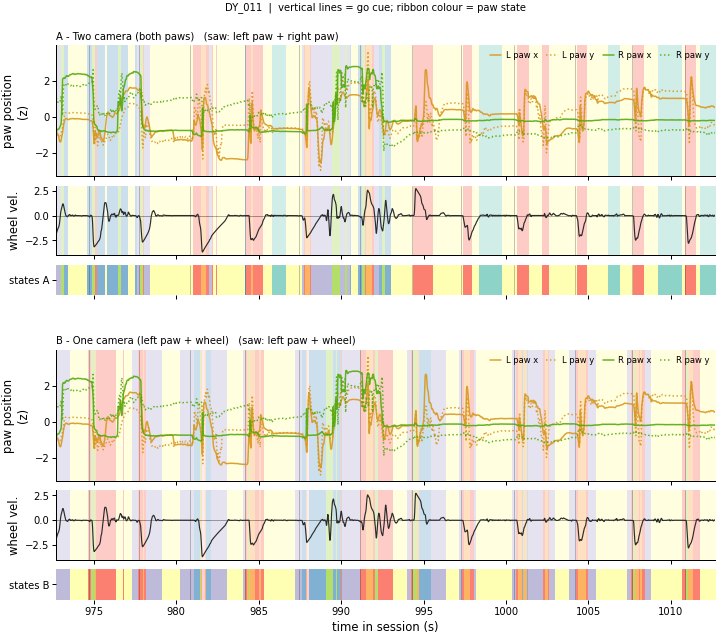

In [7]:
"""
FRAME LEVEL: traces + both state ribbons
"""
traces = load_traces(example_mouse, example_session)
fa = load_frame_states(STATES_A, FIX_A, example_mouse, example_session)
fb = load_frame_states(STATES_B, FIX_B, example_mouse, example_session)

# The two state arrays can differ in length by a few frames, so merge on Bin, not index.
frame = (traces.merge(fa.rename(columns={'state': 'state_a'}), on='Bin', how='inner')
               .merge(fb.rename(columns={'state': 'state_b'}), on='Bin', how='inner'))
print(f'{len(frame):,} frames aligned across traces / A / B')

WINDOW_S = 40                              # seconds to show
gocues = np.sort(frame['goCueTrigger_times'].dropna().unique())
t0 = gocues[len(gocues) // 2] - 2 if len(gocues) else frame['Bin'].iloc[0]
win = frame[(frame['Bin'] >= t0) & (frame['Bin'] < t0 + WINDOW_S)].reset_index(drop=True)
t = win['Bin'].to_numpy()

# once Part 2 has run, B is drawn in A's label space so the two ribbons are comparable
_perm = globals().get('perm_paw', np.arange(K_PAW))
if 'perm_paw' not in globals():
    print('perm_paw not defined yet -- B is in its own labels. Re-run after Part 2.')

# One block per segmentation: the same traces, with that segmentation's states
# underneath, both as a background tint on the traces and as a strip below them.
# Duplicated on purpose -- each segmentation sits against the behaviour it labels.
BLOCKS = [(SHORT_A, LABEL_A, win['state_a'].to_numpy(), 'saw: left paw + right paw'),
          (SHORT_B, LABEL_B, _perm[win['state_b'].to_numpy()], 'saw: left paw + wheel')]

SHADE_ALPHA = 0.4       # how strongly the state colours tint the trace panels

fig = plt.figure(figsize=(ps.FIG['double'][0], 6.0))
outer = fig.add_gridspec(len(BLOCKS), 1, hspace=0.22)
axes = []
for k, (short, long, state, saw) in enumerate(BLOCKS):
    inner = outer[k].subgridspec(3, 1, height_ratios=[3, 1.6, 0.7], hspace=0.12)
    ax_paw, ax_wheel, ax_rib = (fig.add_subplot(inner[j], sharex=axes[0] if axes else None)
                                for j in range(3))
    axes += [ax_paw, ax_wheel, ax_rib]

    for side in ('l', 'r'):
        for axis, ls in (('x', '-'), ('y', ':')):
            ax_paw.plot(t, stats.zscore(win[f'{side}_paw_{axis}'], nan_policy='omit'),
                        color=PAW_COLOR[side], ls=ls, lw=0.9, alpha=0.9,
                        label=f'{side.upper()} paw {axis}')
    ax_paw.legend(ncol=4, fontsize=5, frameon=False, loc='upper right')
    ax_paw.set_ylabel('paw position\n(z)')
    ax_paw.set_title(f'{short} - {long}   ({saw})', fontsize=6, loc='left')

    ax_wheel.plot(t, win['avg_wheel_vel'], color=ps.STATE_INK, lw=0.7)
    ps.zero_line(ax_wheel)
    ax_wheel.set_ylabel('wheel vel.')

    # THE SEGMENTATION, AS A COLOUR BACKGROUND UNDER BOTH SETS OF TRACES
    shade_states(ax_paw, t, state, alpha=SHADE_ALPHA)
    shade_states(ax_wheel, t, state, alpha=SHADE_ALPHA)

    # ...and once more as a crisp strip, for reading state identity off dense stretches
    ribbon(ax_rib, t, state, f'states {short}')

    for ax in (ax_paw, ax_wheel, ax_rib):
        ax.tick_params(labelbottom=False)   # only the bottom-most axis keeps its ticks
        for g in gocues[(gocues >= t[0]) & (gocues <= t[-1])]:
            ax.axvline(g, color='k', lw=0.4, alpha=0.35, zorder=0)

axes[-1].tick_params(labelbottom=True)
axes[-1].set_xlabel('time in session (s)')
axes[-1].set_xlim(t[0], t[-1])
fig.suptitle(f'{example_mouse}  |  vertical lines = go cue; ribbon colour = paw state',
             y=0.94, fontsize=6)
plt.show()

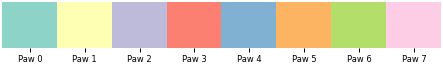

In [8]:
"""
PAW-STATE COLOUR KEY (shared by every ribbon and raster below)
"""
fig, ax = plt.subplots(figsize=(ps.FIG['wide'][0], 0.5))
ax.imshow(np.arange(K_PAW)[None, :], aspect='auto', cmap=PAW_CMAP, norm=PAW_NORM)
ax.set_xticks(range(K_PAW))
ax.set_xticklabels([f'Paw {i}' for i in range(K_PAW)], fontsize=5)
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.show()

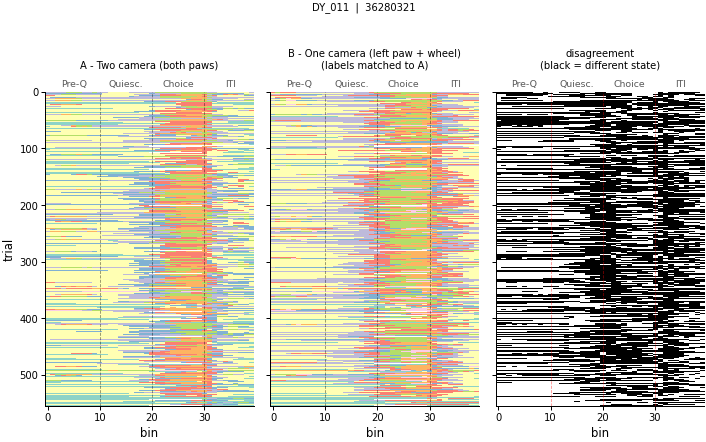

In [9]:
"""
SYLLABLE LEVEL: one session as a trial x bin raster, A next to B

Each trial is the four epochs concatenated in order, 10 bins each -> 40 bins per trial.
Before Part 2 has run this uses raw labels; afterwards it picks up `perm_paw` from the
namespace and shows B relabeled onto A, which is the version worth looking at.
"""
def trial_matrix(paw, rows_mask):
    """(n_trials, 4 * N_BINS): the four epochs concatenated in EPOCHS order."""
    sub = meta.loc[rows_mask]
    trials = np.sort(sub['trial_id'].unique())
    tidx = {tr: i for i, tr in enumerate(trials)}
    eidx = {e: i for i, e in enumerate(EPOCHS)}
    M = np.full((len(trials), len(EPOCHS) * N_BINS), np.nan)
    for row, tr, ep in zip(np.flatnonzero(rows_mask), sub['trial_id'], sub['broader_label']):
        if ep in eidx:
            M[tidx[tr], eidx[ep] * N_BINS:(eidx[ep] + 1) * N_BINS] = paw[row]
    return M, trials


TRIAL_SLICE = slice(None)      # e.g. slice(0, 80) to zoom in on the first 80 trials

mask = (meta['session'] == example_session).to_numpy()
MA, trials = trial_matrix(paw_a, mask)
MB, _ = trial_matrix(paw_b, mask)
MA, MB = MA[TRIAL_SLICE], MB[TRIAL_SLICE]

_perm = globals().get('perm_paw', np.arange(K_PAW))
MB_matched = np.where(np.isnan(MB), np.nan, np.take(_perm, np.nan_to_num(MB).astype(int)))

fig, axs = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 3.4), sharey=True,
                        gridspec_kw={'wspace': 0.08})
for ax, M, ttl in [(axs[0], MA, f'A - {LABEL_A}'),
                   (axs[1], MB_matched, f'B - {LABEL_B}\n(labels matched to A)')]:
    ax.imshow(M, aspect='auto', interpolation='nearest', cmap=PAW_CMAP, norm=PAW_NORM)
    ps.epoch_lines(ax, n_bins=len(EPOCHS) * N_BINS, label=True, names=ps.EPOCH_SHORT)
    ax.set_title(ttl, fontsize=6, pad=14)      # clear the epoch labels
    ax.set_xlabel('bin')

axs[2].imshow((MA != MB_matched).astype(float), aspect='auto', interpolation='nearest',
              cmap='Greys', vmin=0, vmax=1)
ps.epoch_lines(axs[2], n_bins=len(EPOCHS) * N_BINS, label=True, names=ps.EPOCH_SHORT, color='r')
axs[2].set_title('disagreement\n(black = different state)', fontsize=6, pad=14)
axs[2].set_xlabel('bin')
axs[0].set_ylabel('trial')
fig.suptitle(f'{example_mouse}  |  {example_session[:8]}', y=1.10, fontsize=6)
plt.show()

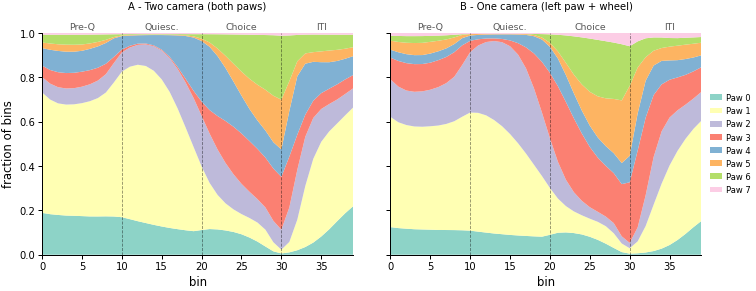

In [10]:
"""
SYLLABLE LEVEL: population state profile across the trial, A vs B

Fraction of bins in each paw state at each point of the trial, pooled over all sessions.
Two segmentations can disagree bin-by-bin and still describe the same trial structure --
this is the check for whether they do.
"""
def state_profile(paw, perm=None):
    P = np.zeros((K_PAW, len(EPOCHS) * N_BINS))
    eidx = {e: i for i, e in enumerate(EPOCHS)}
    ep_codes = meta['broader_label'].map(eidx).to_numpy()
    for e in range(len(EPOCHS)):
        rows = ep_codes == e
        block, ok = paw[rows], valid[rows]
        for b in range(N_BINS):
            lab = block[:, b][ok[:, b]].astype(int)
            if perm is not None:
                lab = perm[lab]
            P[:, e * N_BINS + b] = occupancy(lab)
    return P


PROF_A = state_profile(paw_a)
PROF_B = state_profile(paw_b, globals().get('perm_paw'))

fig, axs = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 2.4), sharey=True,
                        gridspec_kw={'wspace': 0.12})
x = np.arange(len(EPOCHS) * N_BINS)
for ax, P, ttl in [(axs[0], PROF_A, f'A - {LABEL_A}'),
                   (axs[1], PROF_B, f'B - {LABEL_B}')]:
    ax.stackplot(x, P, colors=[ps.SYLLABLE[f'Paw {i}'] for i in range(K_PAW)],
                 labels=[f'Paw {i}' for i in range(K_PAW)])
    ps.epoch_lines(ax, n_bins=len(EPOCHS) * N_BINS, label=True, names=ps.EPOCH_SHORT)
    ax.set_xlim(0, len(x) - 1)
    ax.set_ylim(0, 1)
    ax.set_title(ttl, fontsize=6, pad=14)      # clear the epoch labels
    ax.set_xlabel('bin')
axs[0].set_ylabel('fraction of bins')
axs[1].legend(ncol=1, fontsize=5, frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.show()

---
# 2. Correlating pairs of states

Cluster indices from two independent fits mean nothing to each other, so the comparison goes in
three steps:

1. **Contingency** `P(B = j | A = i)` — the raw 8×8 table of which B-state each A-state falls
   into. This is the honest picture and needs no matching at all.
2. **Matching** — Hungarian assignment on that table gives the one-to-one permutation of B onto A
   that maximises agreement. That agreement is the *ceiling* over all relabelings, and is the
   number to quote, alongside Cohen's κ, ARI and AMI (which are matching-free).
3. **Correlation** — each state becomes a binary occupancy time series; correlating them pairwise
   gives an 8×8 matrix (a φ coefficient) comparable across states of very different prevalence.
   Occupancy is then also correlated *across sessions*, which asks a different question: do the two
   segmentations agree about which sessions are movement-heavy, even where they disagree frame by
   frame?

### The four numbers, and why there are four

Two label sets from independent fits can agree in more than one sense, and the measures below
split into two families that answer different questions.

**Need a one-to-one correspondence** (so they run *after* Hungarian matching):

- **Matched agreement** — the fraction of bins where A and B give the same state, once B has been
  relabelled optimally. This is the ceiling over all one-to-one relabellings. Not chance-corrected:
  with one dominant state, a segmentation that always guessed it would already score high, which is
  why `chance (matched)` is reported next to it.
- **Cohen's κ** — the same quantity corrected for the agreement expected from the two marginals
  alone: `κ = (p_obs − p_chance) / (1 − p_chance)`. 0 means no better than the marginals predict,
  1 means identical. It is the honest version of matched agreement.

**Need no correspondence at all** (invariant to any relabelling, so no matching required):

- **ARI, adjusted Rand index** — treats each segmentation as a *partition* of the bins and asks,
  over all pairs of bins, how often the two agree about whether that pair belongs together or
  apart; then corrects for chance. 0 = the partitions are independent, 1 = identical, slightly
  negative = worse than chance.
- **AMI, adjusted mutual information** — the mutual information between the two labelings,
  normalised and chance-corrected. It is the one measure that rewards *systematic many-to-one*
  structure: if A's state 2 reliably splits into B's states 3 and 5, that is a consistent, fully
  informative mapping, but matched agreement and κ punish it as error while AMI counts it as
  agreement.

### The formulas

Written as monospace ASCII on purpose — it renders identically in JupyterLab, VS Code, nbviewer
and GitHub, none of which agree about LaTeX in notebook markdown.

Both measures are built from the same **contingency table** the notebook already computes:

    n_ij = number of bins that A calls state i and B calls state j
    a_i  = sum_j n_ij        (row sums    = A's state occupancies)
    b_j  = sum_i n_ij        (column sums = B's state occupancies)
    N    = sum_ij n_ij       (total bins)

and both take the same shape — *observed, minus what chance gives, over the maximum minus what
chance gives* — which is what makes them comparable across datasets with different k and
different state prevalences.

**Cohen's kappa**, for reference, is the simplest member of that family:

    kappa = (p_obs - p_chance) / (1 - p_chance)

where p_obs = (1/N) * sum_i n_ii after matching, and p_chance = sum_i (a_i/N)(b_i/N).

**Adjusted Rand index.** The Rand index counts *pairs* of bins: a pair is concordant when both
segmentations put the two bins together, or both put them apart. Writing C(x) = x(x-1)/2 for the
number of pairs among x items, the pairs kept together by both segmentations are sum_ij C(n_ij),
and

              sum_ij C(n_ij)  -  E
    ARI = ---------------------------------------
          0.5 * [ sum_i C(a_i) + sum_j C(b_j) ] - E

                     sum_i C(a_i)  *  sum_j C(b_j)
    where      E =  -------------------------------
                              C(N)

E is the expected pair count under the **permutation model**: the two partitions treated as
independent draws with those row and column sums held fixed. Hence ARI = 0 for independent
partitions, 1 when the tables agree exactly, and slightly negative when they agree *less* than
independence predicts. The cell below computes this straight from `counts_paw`, as a check on the
formula.

**Adjusted mutual information.** With empirical probabilities

    p_ij = n_ij / N        p_i = a_i / N        q_j = b_j / N

the mutual information and the marginal entropies are

    MI(A,B) = sum_i sum_j  p_ij * log( p_ij / (p_i * q_j) )

    H(A)    = - sum_i p_i * log(p_i)              (and likewise H(B))

and AMI applies the same chance correction:

                MI(A,B)  -  E[MI]
    AMI = --------------------------------
          0.5 * ( H(A) + H(B) )  -  E[MI]

The `0.5 * (H(A) + H(B))` in the denominator is `sklearn`'s default
`average_method='arithmetic'`; `'max'` and `'geometric'` are the other conventions and give
slightly different numbers, so the choice has to be stated whenever AMI is quoted.

E[MI] is the expectation under the same permutation model. Unlike ARI's, it has **no closed
form** — it is a hypergeometric sum (Vinh, Epps & Bailey, JMLR 2010):

    E[MI] = sum_i sum_j  sum_{n = max(1, a_i + b_j - N)} ^ {min(a_i, b_j)}

                    n            N * n           a_i! b_j! (N-a_i)! (N-b_j)!
                   --- * log( ----------- ) * ---------------------------------------
                    N          a_i * b_j       N! n! (a_i-n)! (b_j-n)! (N-a_i-b_j+n)!

That triple sum is why `adjusted_mutual_info_score` is the slow one here, and why the notebook
hands it a subsample rather than all 8.3M bins.

**Why MI behaves differently from the pair-counting measure.** MI is a function of the joint
distribution alone, so a systematic split — A's state 2 always landing in B's states 3 and 5 —
leaves p_ij concentrated in few cells and MI high. ARI instead counts the bin *pairs* that state 2
held together and that the 3-vs-5 split now pulls apart, and charges for every one of them. Same
table; the gap between the two numbers is exactly the split-and-merge structure.

**So read them together, not separately.** AMI well above matched agreement means the two
segmentations carve up the *same* behaviour with partially different boundaries; AMI near matched
agreement would mean they genuinely disagree about what the mouse is doing. In this dataset AMI on
the 32-syllable alphabet (0.61) sits far above matched agreement (0.52) — the split-and-merge
reading.

In [11]:
"""
CONTINGENCY + OPTIMAL MATCHING (paw states, pooled over every usable bin)
"""
pa = paw_a[valid].astype(int)
pb = paw_b[valid].astype(int)

perm_paw, counts_paw = match_labels(pa, pb, K_PAW)
pb_matched = perm_paw[pb]

# subsample for the information measures; 8.3M bins is far more than they need
sub = slice(None, None, 20)
metrics = pd.Series({
    'matched agreement': (pa == pb_matched).mean(),
    'chance (matched)':  (occupancy(pa) * occupancy(pb_matched)).sum(),
    "Cohen's kappa":     cohen_kappa_score(pa[sub], pb_matched[sub]),
    'adjusted Rand':     adjusted_rand_score(pa[sub], pb[sub]),
    'adjusted MI':       adjusted_mutual_info_score(pa[sub], pb[sub]),
}, name='paw states')
display(metrics.to_frame().style.format('{:.3f}'))
print('matched permutation  B -> A:', {int(j): int(perm_paw[j]) for j in range(K_PAW)})

# ARI straight from the contingency table, to check the formula in the cell above.
# (E[MI] has no closed form, so AMI is left to sklearn.)
def ari_from_contingency(n):
    def comb2(x):
        return x * (x - 1) / 2
    a, b, N = n.sum(1), n.sum(0), n.sum()
    index = comb2(n).sum()
    expected = comb2(a).sum() * comb2(b).sum() / comb2(N)
    maximum = 0.5 * (comb2(a).sum() + comb2(b).sum())
    return (index - expected) / (maximum - expected)


print(f'ARI from contingency (all {counts_paw.sum():,} bins): '
      f'{ari_from_contingency(counts_paw):.4f}   '
      f'| sklearn on the 1-in-20 subsample: {metrics["adjusted Rand"]:.4f}')

,paw states
matched agreement,0.519
chance (matched),0.199
Cohen's kappa,0.401
adjusted Rand,0.352
adjusted MI,0.418


matched permutation  B -> A: {0: 0, 1: 1, 2: 2, 3: 4, 4: 7, 5: 3, 6: 6, 7: 5}
ARI from contingency (all 8,265,346 bins): 0.3479   | sklearn on the 1-in-20 subsample: 0.3518


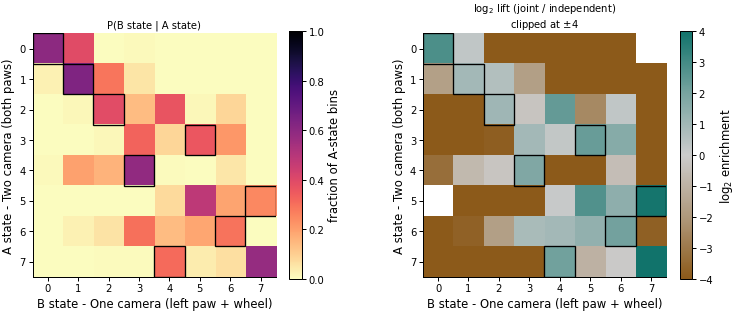

,B0,B1,B2,B3,B4,B5,B6,B7
A0,0.60,0.39,0.00,0.01,0.00,0.00,0.00,0.00
A1,0.03,0.63,0.29,0.05,0.00,0.00,0.00,0.00
A2,0.00,0.01,0.39,0.14,0.36,0.01,0.08,0.00
A3,0.00,0.00,0.01,0.33,0.08,0.36,0.22,0.00
A4,0.01,0.20,0.16,0.59,0.00,0.00,0.05,0.00
A5,0.00,0.00,0.00,0.00,0.08,0.48,0.19,0.25
A6,0.00,0.02,0.06,0.30,0.14,0.19,0.29,0.00
A7,0.00,0.00,0.01,0.00,0.31,0.04,0.07,0.58


In [12]:
"""
THE 8x8 TABLES
"""
row_norm = counts_paw / counts_paw.sum(1, keepdims=True)          # P(B=j | A=i)
joint = counts_paw / counts_paw.sum()
# lift: how much more often (i, j) co-occur than if the two labelings were independent
expected = np.outer(joint.sum(1), joint.sum(0))
lift = np.log2(np.where(joint > 0, joint, np.nan) / expected)

fig, axs = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 3.0),
                        gridspec_kw={'wspace': 0.45})

im = axs[0].imshow(row_norm, cmap='magma_r', vmin=0, vmax=1)
axs[0].set_title('P(B state | A state)', fontsize=6)
fig.colorbar(im, ax=axs[0], fraction=0.046, label='fraction of A-state bins')

# a near-empty cell pair can give a lift of -15, which would flatten every informative
# cell, so the scale is clipped at +/- LIFT_VMAX (2**4 = 16x enrichment or depletion)
LIFT_VMAX = 4
im = axs[1].imshow(np.clip(lift, -LIFT_VMAX, LIFT_VMAX), cmap=ps.DIVERGING_CMAP,
                   vmin=-LIFT_VMAX, vmax=LIFT_VMAX)
axs[1].set_title('log$_2$ lift (joint / independent)\n'
                 f'clipped at $\\pm${LIFT_VMAX}', fontsize=6)
fig.colorbar(im, ax=axs[1], fraction=0.046, label='log$_2$ enrichment')

for ax in axs:
    ax.set_xticks(range(K_PAW))
    ax.set_yticks(range(K_PAW))
    ax.set_xlabel(f'B state - {LABEL_B}')
    ax.set_ylabel(f'A state - {LABEL_A}')
    # the optimal matching, as open squares
    for j, i in enumerate(perm_paw):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec='k', lw=0.8))
plt.show()

display(pd.DataFrame(row_norm, index=[f'A{i}' for i in range(K_PAW)],
                     columns=[f'B{j}' for j in range(K_PAW)])
        .style.format('{:.2f}').background_gradient(cmap='magma_r', vmin=0, vmax=1))

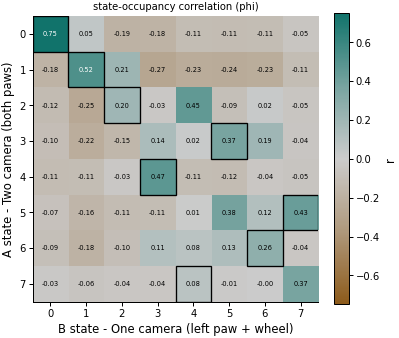

,A state,B state,r (matched pair),occupancy A,occupancy B,recall of A by matched B
0,0,0,0.749,0.121,0.084,0.599
1,1,1,0.523,0.394,0.326,0.633
2,2,2,0.197,0.127,0.190,0.388
3,3,5,0.370,0.092,0.073,0.358
4,4,3,0.469,0.134,0.170,0.586
5,5,7,0.426,0.050,0.017,0.248
6,6,6,0.264,0.074,0.069,0.293
7,7,4,0.080,0.007,0.072,0.311


In [13]:
"""
PAIRWISE STATE CORRELATION (phi): each state as a binary occupancy time series
"""
onehot_a = np.eye(K_PAW, dtype=np.float32)[pa]
onehot_b = np.eye(K_PAW, dtype=np.float32)[pb]


def cross_corr(X, Y):
    Xz = (X - X.mean(0)) / X.std(0)
    Yz = (Y - Y.mean(0)) / Y.std(0)
    return (Xz.T @ Yz) / len(X)


R_paw = cross_corr(onehot_a, onehot_b)

fig, ax = plt.subplots(figsize=ps.FIG['square'])
im = ax.imshow(R_paw, cmap=ps.CORR_CMAP, norm=ps.corr_norm(vmax=np.abs(R_paw).max()))
ax.set_xticks(range(K_PAW))
ax.set_yticks(range(K_PAW))
ax.set_xlabel(f'B state - {LABEL_B}')
ax.set_ylabel(f'A state - {LABEL_A}')
ax.set_title('state-occupancy correlation (phi)', fontsize=6)
for j, i in enumerate(perm_paw):
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec='k', lw=0.8))
for i in range(K_PAW):
    for j in range(K_PAW):
        ax.text(j, i, f'{R_paw[i, j]:.2f}', ha='center', va='center', fontsize=4,
                color='k' if abs(R_paw[i, j]) < 0.5 else 'w')
fig.colorbar(im, ax=ax, fraction=0.046, label='r')
plt.show()

matched_r = pd.DataFrame({
    'A state': perm_paw,
    'B state': np.arange(K_PAW),
    'r (matched pair)': [R_paw[perm_paw[j], j] for j in range(K_PAW)],
    'occupancy A': occupancy(pa)[perm_paw],
    'occupancy B': occupancy(pb),
    'recall of A by matched B': [counts_paw[perm_paw[j], j] / counts_paw[perm_paw[j]].sum()
                                 for j in range(K_PAW)],
}).sort_values('A state').reset_index(drop=True)
display(matched_r.style.format({'r (matched pair)': '{:.3f}', 'occupancy A': '{:.3f}',
                                'occupancy B': '{:.3f}',
                                'recall of A by matched B': '{:.3f}'}))

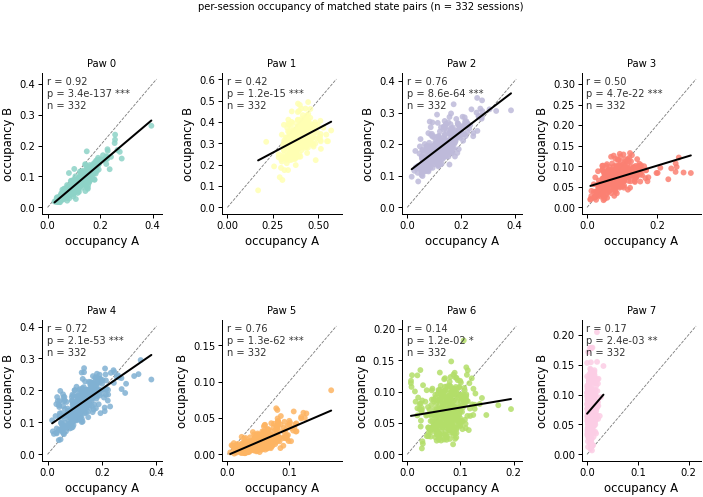

In [14]:
"""
CROSS-SESSION OCCUPANCY: do the two segmentations rank sessions the same way?
"""
sess_codes, sess_names = pd.factorize(meta['session'])
row_sess = np.repeat(sess_codes[:, None], N_BINS, axis=1)[valid]

occ_a = np.zeros((len(sess_names), K_PAW))
occ_b = np.zeros((len(sess_names), K_PAW))
np.add.at(occ_a, (row_sess, pa), 1)
np.add.at(occ_b, (row_sess, pb_matched), 1)
occ_a /= occ_a.sum(1, keepdims=True)
occ_b /= occ_b.sum(1, keepdims=True)

fig, axs = plt.subplots(2, 4, figsize=(ps.FIG['double'][0], 4.2),
                        gridspec_kw={'hspace': 0.75, 'wspace': 0.5})
for i, ax in enumerate(axs.ravel()):
    ps.corr_panel(ax, occ_a[:, i], occ_b[:, i], color=ps.SYLLABLE[f'Paw {i}'],
                  method='pearson', xlabel='occupancy A', ylabel='occupancy B')
    hi = max(occ_a[:, i].max(), occ_b[:, i].max()) * 1.05
    ax.plot([0, hi], [0, hi], color=ps.NEUTRAL, lw=0.5, ls='--', zorder=0)
    ax.set_title(f'Paw {i}', fontsize=6)
fig.suptitle(f'per-session occupancy of matched state pairs (n = {len(sess_names)} sessions)',
             y=1.02, fontsize=6)
plt.show()

,count,mean,std,min,25%,50%,75%,max
agree_global_perm,332.000,0.515,0.046,0.335,0.482,0.517,0.547,0.627
agree_session_perm,332.000,0.525,0.043,0.411,0.494,0.525,0.554,0.635
ARI,332.000,0.357,0.055,0.187,0.322,0.355,0.391,0.498


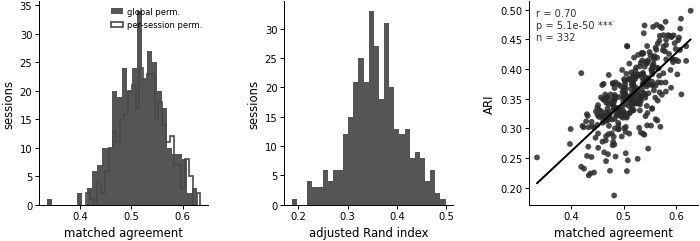

sessions where the two segmentations correspond worst:


,mouse_name,session,n_bins,agree_global_perm,ARI
15,NYU-47,fc43390d-457e-463a-9fd4-b94a0a8b48f5,23140,0.481590,0.186828
87,CSHL053,12dc8b34-b18e-4cdd-90a9-da134a9be79c,35350,0.433239,0.220763
306,NYU-40,8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8,21498,0.436459,0.223987
103,CSHL053,810b1e07-009e-4ebe-930a-915e4cd8ece4,18430,0.443299,0.225554
323,SWC_066,f4ffb731-8349-4fe4-806e-0232a84e52dd,33690,0.505907,0.227996
96,CSHL053,0deb75fb-9088-42d9-b744-012fb8fc4afb,25890,0.473619,0.228569
293,NYU-30,5ec72172-3901-4771-8777-6e9490ca51fc,17001,0.424269,0.232028
102,NYU-30,77e6dc6a-66ed-433c-b1a2-778c914f523c,21252,0.418878,0.235366
307,NYU-39,ee212778-3903-4f5b-ac4b-a72f22debf03,20760,0.466185,0.244785
106,NYU-47,288bfbf3-3700-4abe-b6e4-130b5c541e61,20030,0.507639,0.246141


In [15]:
"""
PER-SESSION AGREEMENT: is the divergence uniform, or concentrated in some sessions?

Two matchings per session: the GLOBAL permutation (fixed above) and one refit within that
session. The gap between them says whether states are consistently mis-corresponded across
the whole dataset, or re-shuffled session by session.
"""
rows = []
for s, name in enumerate(sess_names):
    sel = row_sess == s
    xa, xb = pa[sel], pb[sel]
    if len(xa) < 500:
        continue
    perm_s, _ = match_labels(xa, xb, K_PAW)
    ss = slice(None, None, 5)
    rows.append({
        'session': name,
        'mouse_name': meta.loc[meta['session'] == name, 'mouse_name'].iloc[0],
        'n_bins': len(xa),
        'agree_global_perm': (xa == perm_paw[xb]).mean(),
        'agree_session_perm': (xa == perm_s[xb]).mean(),
        'ARI': adjusted_rand_score(xa[ss], xb[ss]),
        'n_states_A': len(np.unique(xa)),
        'n_states_B': len(np.unique(xb)),
    })
per_session = pd.DataFrame(rows)
display(per_session[['agree_global_perm', 'agree_session_perm', 'ARI']]
        .describe().T.style.format('{:.3f}'))

fig, axs = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 2.2),
                        gridspec_kw={'wspace': 0.45})
axs[0].hist(per_session['agree_global_perm'], bins=30, color=ps.STATE_INK, alpha=0.8,
            label='global perm.')
axs[0].hist(per_session['agree_session_perm'], bins=30, histtype='step',
            color=ps.SYLLABLE['Lick'], label='per-session perm.')
axs[0].set_xlabel('matched agreement')
axs[0].set_ylabel('sessions')
axs[0].legend(fontsize=5, frameon=False)

axs[1].hist(per_session['ARI'], bins=30, color=ps.STATE_INK, alpha=0.8)
axs[1].set_xlabel('adjusted Rand index')
axs[1].set_ylabel('sessions')

ps.corr_panel(axs[2], per_session['agree_global_perm'].to_numpy(),
              per_session['ARI'].to_numpy(), color=ps.STATE_INK,
              xlabel='matched agreement', ylabel='ARI')
plt.show()

print('sessions where the two segmentations correspond worst:')
display(per_session.nsmallest(10, 'ARI')[['mouse_name', 'session', 'n_bins',
                                          'agree_global_perm', 'ARI']])

,32 syllables
raw agreement,0.450
agreement (paw matched),0.517
Cohen's kappa (paw matched),0.472
adjusted Rand,0.459
adjusted MI,0.609


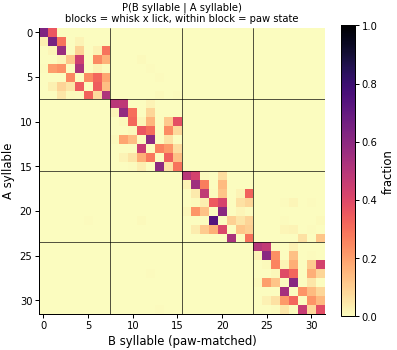

In [16]:
"""
THE SAME COMPARISON ON THE FULL 32-SYLLABLE ALPHABET

Only the paw dimension differs, but downstream analyses consume the whole syllable, so this
is the agreement that actually propagates. Matching is restricted to permutations of the PAW
digit -- whisk/lick are shared, and permuting across them would be meaningless.
"""
sa = SEQ_A[valid].astype(int)
sb = SEQ_B[valid].astype(int)
sb_matched = (sb // K_PAW) * K_PAW + perm_paw[sb % K_PAW]

ss = slice(None, None, 20)
syll_metrics = pd.Series({
    'raw agreement':               (sa == sb).mean(),
    'agreement (paw matched)':     (sa == sb_matched).mean(),
    "Cohen's kappa (paw matched)": cohen_kappa_score(sa[ss], sb_matched[ss]),
    'adjusted Rand':               adjusted_rand_score(sa[ss], sb[ss]),
    'adjusted MI':                 adjusted_mutual_info_score(sa[ss], sb[ss]),
}, name='32 syllables')
display(syll_metrics.to_frame().style.format('{:.3f}'))

C32 = np.zeros((N_SYLL, N_SYLL), dtype=np.int64)
np.add.at(C32, (sa, sb_matched), 1)
denom = C32.sum(1, keepdims=True)
row32 = C32 / np.where(denom > 0, denom, 1)

fig, ax = plt.subplots(figsize=ps.FIG['square'])
im = ax.imshow(row32, cmap='magma_r', vmin=0, vmax=1)
for e in range(K_PAW, N_SYLL, K_PAW):
    ax.axhline(e - 0.5, color='k', lw=0.4)
    ax.axvline(e - 0.5, color='k', lw=0.4)
ax.set_xlabel('B syllable (paw-matched)')
ax.set_ylabel('A syllable')
ax.set_title('P(B syllable | A syllable)\nblocks = whisk x lick, within block = paw state',
             fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.046, label='fraction')
plt.show()

Re-run the two Part-1 raster/profile cells now if you want them drawn with `perm_paw` applied —
they pick it up from the namespace automatically.

---
# 4. Task predictivity

The two segmentations disagree on about half of all bins, but bin-level agreement is not what the
paper rests on. This asks the question that matters instead: **do the two carry the same
information about the task?** — scored on variables *neither* segmentation was fit to, so neither
has a built-in advantage.

Everything is matched between A and B: the same trials, the same folds, the same features, the same
classifier. Only the input file differs, so any gap is attributable to the segmentation.

- **Features** — per trial, the fraction of bins spent in each of the 32 syllables, separately per
  epoch: `4 epochs x 32 syllables = 128` numbers. Bag-of-syllables, so it deliberately throws away
  *order*; a sequence model would be a separate (and more generous) test. Set `FEATURE_EPOCHS` to a
  subset to ask a narrower question — `['Pre-quiescence']` gives the pre-trial version, i.e.
  predicting a trial from behaviour *before* the trial began.
- **Targets** — parsed from `trial_type`, which is
  `<correct|incorrect> <|contrast|> <block> <choice>` (verified against the frame-level
  `states_files` columns; field 4 is the animal's **choice**, not the stimulus side, so stimulus
  side has to be reconstructed by flipping the choice on error trials).
- **Cross-validation** — `GroupKFold` by **session**, so no session appears in both train and test.
  Chance is `1 / n_classes` because everything is scored as balanced accuracy with balanced class
  weights.
- **Statistics** — balanced accuracy is recomputed **per held-out session**, giving 332 paired
  A-vs-B values per target, and compared with a Wilcoxon signed-rank test. Pooling all trials into
  one score would treat 209k trials as independent, which they are not (per session, per mouse).

In [17]:
"""
TASK PREDICTIVITY: PARAMETERS
"""
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score

FEATURE_EPOCHS = EPOCHS          # or e.g. ['Pre-quiescence'] for the pre-trial version
N_SPLITS = 5
MAX_TRIALS = 80000               # subsample cap, for runtime; None uses every trial
RANDOM_STATE = 0

def make_classifier():
    """One classifier definition, used identically for A and B."""
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=500, class_weight='balanced'))

In [18]:
"""
TASK PREDICTIVITY: BUILD THE TRIAL TABLE AND THE TWO FEATURE MATRICES
"""
def syllable_counts(seq):
    """(n_epoch_rows, N_SYLL) count of each syllable in each epoch-row's bins."""
    rows = np.repeat(np.arange(len(seq)), N_BINS)
    flat = seq.ravel()
    ok = ~np.isnan(flat)
    out = np.zeros((len(seq), N_SYLL), dtype=np.float32)
    np.add.at(out, (rows[ok], flat[ok].astype(int)), 1)
    return out


def trial_features(seq, epochs=None):
    """Per-trial epoch x syllable OCCUPANCY -> (n_trials, len(epochs) * N_SYLL).

    Rows are ordered by `trial_names` (below), so the A and B matrices are row-matched.
    """
    epochs = EPOCHS if epochs is None else epochs
    eidx = {e: i for i, e in enumerate(epochs)}
    keep = meta['broader_label'].isin(epochs).to_numpy()
    cnt = syllable_counts(seq[keep])
    X = np.zeros((len(trial_names), len(epochs), N_SYLL), dtype=np.float32)
    X[trial_code[keep], meta.loc[keep, 'broader_label'].map(eidx).to_numpy()] = cnt
    X /= np.maximum(X.sum(2, keepdims=True), 1)          # occupancy, not raw counts
    return X.reshape(len(trial_names), -1)


trial_code, trial_names = pd.factorize(meta['sample'])

# one row per trial, in trial_names order
tm = meta.drop_duplicates('sample').set_index('sample').loc[trial_names]
fields = tm['trial_type'].str.split(expand=True).to_numpy()
trials = pd.DataFrame({
    'session': pd.Series(trial_names).str.split(' ').str[0].to_numpy(),
    'mouse_name': tm['mouse_name'].to_numpy(),
    'feedback': fields[:, 0],                            # correct / incorrect
    'contrast': fields[:, 1],
    'block': fields[:, 2],
    'choice': fields[:, 3],                              # the ANIMAL'S choice
})
# stimulus side: equals the choice on correct trials, the opposite on errors
flip = {'left': 'right', 'right': 'left', 'no_go': 'no_go'}
trials['stim_side'] = np.where(trials['feedback'] == 'correct',
                               trials['choice'], trials['choice'].map(flip))
trials['zero_contrast'] = np.where(trials['contrast'].astype(float) == 0., 'zero', 'nonzero')

X_A = trial_features(SEQ_A, FEATURE_EPOCHS)
X_B = trial_features(SEQ_B, FEATURE_EPOCHS)
print(f'{len(trials):,} trials x {X_A.shape[1]} features '
      f'({len(FEATURE_EPOCHS)} epochs x {N_SYLL} syllables)')
assert X_A.shape == X_B.shape

209,594 trials x 128 features (4 epochs x 32 syllables)


In [19]:
"""
TASK PREDICTIVITY: THE TARGETS

`rows` selects the trials each target is defined on -- errors are needed for feedback but
no_go trials have no side, and block is only a real contrast between 0.2 and 0.8.
"""
TARGETS = {
    'choice (L/R)':      (trials['choice'],        trials['choice'] != 'no_go'),
    'stimulus side (L/R)': (trials['stim_side'],   trials['stim_side'] != 'no_go'),
    'feedback (corr/err)': (trials['feedback'],    pd.Series(True, index=trials.index)),
    'contrast (5-way)':  (trials['contrast'],      pd.Series(True, index=trials.index)),
    'zero contrast':     (trials['zero_contrast'], pd.Series(True, index=trials.index)),
    'block (0.2 vs 0.8)': (trials['block'],        trials['block'] != '0.5'),
}
for name, (y, rows) in TARGETS.items():
    n = int(rows.sum())
    k = y[rows].nunique()
    print(f'{name:22s} n = {n:7,}  classes = {k}  chance = {1 / k:.3f}  '
          f'largest class = {y[rows].value_counts(normalize=True).iloc[0]:.3f}')

choice (L/R)           n = 208,759  classes = 2  chance = 0.500  largest class = 0.505
stimulus side (L/R)    n = 208,759  classes = 2  chance = 0.500  largest class = 0.509
feedback (corr/err)    n = 209,594  classes = 2  chance = 0.500  largest class = 0.819
contrast (5-way)       n = 209,594  classes = 5  chance = 0.200  largest class = 0.223
zero contrast          n = 209,594  classes = 2  chance = 0.500  largest class = 0.883
block (0.2 vs 0.8)     n = 179,716  classes = 2  chance = 0.500  largest class = 0.513


In [20]:
"""
TASK PREDICTIVITY: DECODE EACH TARGET UNDER BOTH SEGMENTATIONS
"""
def decode(X, y, groups):
    """Out-of-fold predictions from GroupKFold, so every trial is predicted exactly once."""
    return cross_val_predict(make_classifier(), X, y,
                             cv=GroupKFold(N_SPLITS), groups=groups, n_jobs=N_SPLITS)


def per_session_scores(y, y_pred, sessions, min_trials=50):
    """Balanced accuracy within each held-out session -> the unit of the paired test."""
    out = {}
    for s in np.unique(sessions):
        sel = sessions == s
        if sel.sum() >= min_trials and len(np.unique(y[sel])) > 1:
            out[s] = balanced_accuracy_score(y[sel], y_pred[sel])
    return pd.Series(out)


rng = np.random.default_rng(RANDOM_STATE)
summary, deltas = [], {}

for name, (y_full, rows) in TARGETS.items():
    idx = np.flatnonzero(rows.to_numpy())
    if MAX_TRIALS is not None and len(idx) > MAX_TRIALS:
        idx = np.sort(rng.choice(idx, size=MAX_TRIALS, replace=False))

    y = y_full.to_numpy()[idx]
    groups = trials['session'].to_numpy()[idx]
    chance = 1 / len(np.unique(y))

    scores, per_sess = {}, {}
    for tag, X in [(SHORT_A, X_A), (SHORT_B, X_B)]:
        pred = decode(X[idx], y, groups)                 # identical folds for A and B
        scores[tag] = balanced_accuracy_score(y, pred)
        per_sess[tag] = per_session_scores(y, pred, groups)

    common = per_sess[SHORT_A].index.intersection(per_sess[SHORT_B].index)
    d = (per_sess[SHORT_B][common] - per_sess[SHORT_A][common])
    deltas[name] = d
    stat, pval = stats.wilcoxon(per_sess[SHORT_A][common], per_sess[SHORT_B][common])

    summary.append({'target': name, 'n_trials': len(idx), 'chance': chance,
                    f'bal.acc {SHORT_A}': scores[SHORT_A],
                    f'bal.acc {SHORT_B}': scores[SHORT_B],
                    'delta (B-A)': scores[SHORT_B] - scores[SHORT_A],
                    'n_sessions': len(common),
                    'median per-session delta': d.median(),
                    'mean per-session delta': d.mean(),
                    'wilcoxon p': pval})
    print(f'{name:22s} A = {scores[SHORT_A]:.3f}  B = {scores[SHORT_B]:.3f}  '
          f'(chance {chance:.3f})  per-session median delta = {d.median():+.4f}  p = {pval:.2g}')

summary = pd.DataFrame(summary)
display(summary.style.format({'chance': '{:.3f}', f'bal.acc {SHORT_A}': '{:.3f}',
                              f'bal.acc {SHORT_B}': '{:.3f}', 'delta (B-A)': '{:+.4f}',
                              'median per-session delta': '{:+.4f}',
                              'mean per-session delta': '{:+.4f}',
                              'wilcoxon p': '{:.2g}', 'n_trials': '{:,}'}))

choice (L/R)           A = 0.589  B = 0.569  (chance 0.500)  per-session median delta = -0.0160  p = 0.0051
stimulus side (L/R)    A = 0.559  B = 0.550  (chance 0.500)  per-session median delta = -0.0074  p = 0.058
feedback (corr/err)    A = 0.911  B = 0.916  (chance 0.500)  per-session median delta = +0.0000  p = 0.036
contrast (5-way)       A = 0.298  B = 0.300  (chance 0.200)  per-session median delta = -0.0002  p = 0.44
zero contrast          A = 0.651  B = 0.653  (chance 0.500)  per-session median delta = +0.0022  p = 0.27
block (0.2 vs 0.8)     A = 0.557  B = 0.542  (chance 0.500)  per-session median delta = -0.0125  p = 0.0025


,target,n_trials,chance,bal.acc A,bal.acc B,delta (B-A),n_sessions,median per-session delta,mean per-session delta,wilcoxon p
0,choice (L/R),"80,000",0.500,0.589,0.569,-0.0205,332,-0.0160,-0.0155,0.0051
1,stimulus side (L/R),"80,000",0.500,0.559,0.550,-0.0094,332,-0.0074,-0.0072,0.058
2,feedback (corr/err),"80,000",0.500,0.911,0.916,+0.0050,332,+0.0000,+0.0048,0.036
3,contrast (5-way),"80,000",0.200,0.298,0.300,+0.0023,332,-0.0002,+0.0019,0.44
4,zero contrast,"80,000",0.500,0.651,0.653,+0.0024,332,+0.0022,+0.0024,0.27
5,block (0.2 vs 0.8),"80,000",0.500,0.557,0.542,-0.0152,332,-0.0125,-0.0108,0.0025


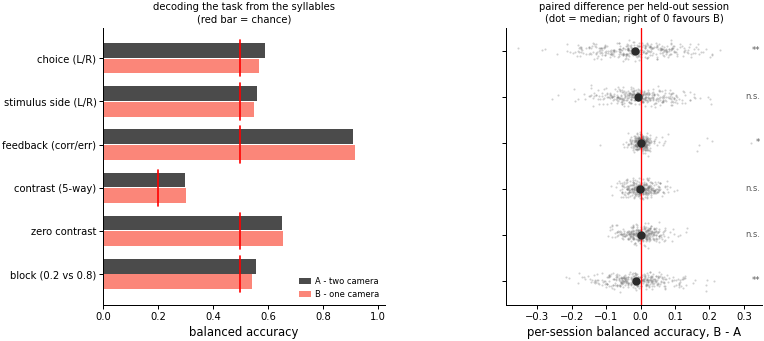

In [21]:
"""
TASK PREDICTIVITY: THE FIGURE
"""
fig, axs = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 3.0),
                        gridspec_kw={'wspace': 0.45, 'width_ratios': [1.1, 1]})

# left: decoding accuracy, A vs B, against chance
yy = np.arange(len(summary))[::-1]
axs[0].barh(yy + 0.18, summary[f'bal.acc {SHORT_A}'], height=0.34,
            color=ps.STATE_INK, alpha=0.85, label=f'{SHORT_A} - two camera')
axs[0].barh(yy - 0.18, summary[f'bal.acc {SHORT_B}'], height=0.34,
            color=ps.SYLLABLE['Paw 3'], alpha=0.95, label=f'{SHORT_B} - one camera')
for k, ch in zip(yy, summary['chance']):
    axs[0].plot([ch, ch], [k - 0.42, k + 0.42], color='r', lw=1.0, zorder=3)
axs[0].set_yticks(yy)
axs[0].set_yticklabels(summary['target'])
axs[0].set_xlabel('balanced accuracy')
axs[0].set_xlim(0, max(summary[[f'bal.acc {SHORT_A}', f'bal.acc {SHORT_B}']].to_numpy().max() * 1.12, 0.6))
axs[0].legend(fontsize=5, frameon=False, loc='lower right')
axs[0].set_title('decoding the task from the syllables\n(red bar = chance)', fontsize=6)

# right: paired per-session differences
for k, (name, pval) in zip(yy, zip(summary['target'], summary['wilcoxon p'])):
    d = deltas[name].to_numpy()
    axs[1].scatter(d, np.full(len(d), k) + rng.normal(0, 0.09, len(d)),
                   s=1.5, color=ps.NEUTRAL, alpha=0.35, linewidths=0)
    axs[1].plot(np.median(d), k, 'o', ms=4, color=ps.STATE_INK, zorder=3)
    axs[1].text(0.99, k, ps.stars(pval), transform=axs[1].get_yaxis_transform(),
                ha='right', va='center', fontsize=5, color='0.35')
axs[1].axvline(0, color='r', lw=0.8)
axs[1].set_yticks(yy)
axs[1].set_yticklabels([])
axs[1].set_xlabel('per-session balanced accuracy, B - A')
axs[1].set_title('paired difference per held-out session\n(dot = median; right of 0 favours B)',
                 fontsize=6)
plt.show()

### Reading this section

The comparison to make is **A vs B on the same row**, not the absolute heights. A bag-of-syllables
occupancy vector with no ordering is a deliberately weak decoder, so the absolute numbers are a
floor on what these syllables carry, not a ceiling — the point is whether the floor moves when the
second camera is removed.

Three outcomes and what each would mean:

- **Both bars equal, per-session deltas centred on 0.** The second camera buys no task information
  the wheel does not already supply. This is the result that licenses the one-camera pipeline, and
  it holds regardless of the ~50% bin-level agreement.
- **B below A, and specifically on `choice` / `stimulus side`.** The right paw was carrying
  laterality that the wheel cannot recover — exactly the asymmetry predicted in section 6b. This is
  the one failure mode that would actually matter, because side is the task's core variable.
- **B above A.** Not impossible, and not a paradox: the wheel is a cleaner, better-timed signal than
  a second tracked paw, so replacing right-paw tracking noise with wheel velocity can raise
  predictivity. If this happens, the interesting follow-up is whether it concentrates in sessions
  with poor right-camera QC.

Read the **median and mean per-session delta together with the p-value**. A Wilcoxon signed-rank
test can be significant while the median delta is exactly 0.000: the test is on the ranks of the
signed differences, so a large number of sessions differing by a hair in the same direction is
enough. When that happens the honest statement is "consistent in sign, negligible in size", not
"B is worse".

A caveat to keep attached to any of them: `GroupKFold` holds out sessions, not mice, so a mouse can
appear in both train and test. That is the right choice for *task* variables (they are properties of
the trial, not the animal) but it would be wrong for anything mouse-identity-flavoured, where the
grouping has to be by mouse.

---
# 5. Predicting the paws and the wheel from the states

Section 4 asked whether the two segmentations carry the same information about the **task**. This
asks whether they carry the same information about the **behaviour** — and it is built to avoid the
trap that makes a left-paw reconstruction uninformative.

The setup is a 3 x 2 grid. Three continuous targets, and for each one, how much of its variance the
state sequence explains under each segmentation:

|  | A saw it? | B saw it? |
|---|---|---|
| **right paw** | yes | **no** |
| **left paw** | yes | yes |
| **wheel** | **no** | yes |

The diagonal cases are rigged and are only there as anchors: A must win on the right paw and B must
win on the wheel, because those are direct inputs. **The number that matters is how much A beats B
on the right paw** — a signal B has no access to at all. If B's states track the right paw nearly as
well as A's, the wheel is an adequate stand-in for the second camera and the one-camera pipeline
loses little. The left-paw row, which both segmentations saw, calibrates the scale: it says how big
a gap arises from the fitting alone, with no information difference.

Details that make the comparison fair:

- **Target** = mean wavelet amplitude over the 0.5-8 Hz discovery bands (both axes for a paw), log
  transformed, then **z-scored within session**. The log matters: raw wavelet amplitude is heavy
  tailed, and without it a handful of large-movement frames would decide R^2. The per-session
  z-score matters because tracking units and lighting differ between sessions.
- **Model** = the state label and nothing else: predict each frame by the mean target value of its
  state. So R^2 is literally "how much of this signal does knowing the state buy you", with no
  regression weights to overfit.
- **Cross-validation** = `GroupKFold` by session, so per-state means are learned on other animals'
  sessions and applied out of sample.
- **Control** = the same states circularly shifted within each session. That preserves each
  segmentation's state marginals and dwell times exactly and destroys only the alignment to the
  behaviour, so its R^2 is the floor.

In [22]:
"""
RIGHT PAW PREDICTION: PARAMETERS AND TARGETS
"""
WAVELET_PAW = base_path + 'paw_wavelets/'          # both paws, all scales (two-camera set)
WAVELET_WHEEL = base_path + 'wheel_wavelets/'

# the 0.5-8 Hz discovery bands: exactly the scales the KMeans clusters were defined on
SCALES = ['0.5', '1.0', '2.0', '4.0', '8.0']
TARGET_COLS = {
    'right paw': [f'r_paw_{ax}{s}' for ax in 'xy' for s in SCALES],
    'left paw':  [f'l_paw_{ax}{s}' for ax in 'xy' for s in SCALES],
    'wheel':     [f'avg_wheel_vel{s}' for s in SCALES],
}
# which segmentation actually had this signal as an input
SAW = {'right paw': (SHORT_A,), 'left paw': (SHORT_A, SHORT_B), 'wheel': (SHORT_B,)}

N_SESSIONS_RP = None        # None = every session; set an int to sample fewer while iterating
FRAMES_PER_SESSION = 8000   # frames kept per session, subsampled uniformly
RP_SPLITS = 5


def band_power(df, cols):
    """Mean wavelet amplitude over `cols`, log-transformed and z-scored within session.

    log first: raw amplitude is heavy tailed, and R^2 on the raw scale would be decided by
    a handful of large-movement frames.
    """
    v = np.log(np.asarray(df[cols], dtype=float).mean(axis=1) + 1e-6)
    return stats.zscore(v, nan_policy='omit')

In [23]:
"""
RIGHT PAW PREDICTION: BUILD THE FRAME TABLE
"""
wav_files = sorted(f for f in os.listdir(WAVELET_PAW) if f.startswith('paw_vel_wavelets_'))
rp_rng = np.random.default_rng(RANDOM_STATE)
if N_SESSIONS_RP is not None and N_SESSIONS_RP < len(wav_files):
    wav_files = [wav_files[i] for i in
                 np.sort(rp_rng.choice(len(wav_files), N_SESSIONS_RP, replace=False))]

paw_cols = TARGET_COLS['right paw'] + TARGET_COLS['left paw']
chunks = []
for f in wav_files:
    stem = f[len('paw_vel_wavelets_'):]
    session, mouse_name = stem[:36], stem[37:]
    try:
        pw = pd.read_parquet(WAVELET_PAW + f, columns=['Bin'] + paw_cols)
        wh = pd.read_parquet(f'{WAVELET_WHEEL}wheel_vel_wavelets_{session}_{mouse_name}',
                             columns=['Bin'] + TARGET_COLS['wheel'])
        fa_ = load_frame_states(STATES_A, FIX_A, mouse_name, session)
        fb_ = load_frame_states(STATES_B, FIX_B, mouse_name, session)
    except (FileNotFoundError, OSError):
        continue

    d = (pw.merge(wh, on='Bin', how='inner')
           .merge(fa_.rename(columns={'state': SHORT_A}), on='Bin', how='inner')
           .merge(fb_.rename(columns={'state': SHORT_B}), on='Bin', how='inner'))
    if len(d) < FRAMES_PER_SESSION // 2:
        continue

    out = pd.DataFrame({name: band_power(d, cols) for name, cols in TARGET_COLS.items()})
    out[SHORT_A], out[SHORT_B] = d[SHORT_A].to_numpy(), d[SHORT_B].to_numpy()
    out['session'], out['mouse_name'] = session, mouse_name
    out = out.dropna()
    if len(out) > FRAMES_PER_SESSION:
        out = out.iloc[np.sort(rp_rng.choice(len(out), FRAMES_PER_SESSION, replace=False))]
    chunks.append(out)

FRAMES = pd.concat(chunks, ignore_index=True)
print(f'{len(FRAMES):,} frames from {FRAMES["session"].nunique()} sessions / '
      f'{FRAMES["mouse_name"].nunique()} mice')

2,656,000 frames from 332 sessions / 101 mice


In [24]:
"""
RIGHT PAW PREDICTION: VARIANCE EXPLAINED BY STATE IDENTITY
"""
def state_mean_predictions(y, state, groups, k=K_PAW, min_n=20):
    """Out-of-fold prediction of y by the training-set mean of its state."""
    pred = np.full(len(y), np.nan)
    for tr, te in GroupKFold(RP_SPLITS).split(y, groups=groups):
        m = np.full(k, y[tr].mean())
        for s in range(k):
            sel = state[tr] == s
            if sel.sum() >= min_n:
                m[s] = y[tr][sel].mean()
        pred[te] = m[state[te]]
    return pred


def r2(y, pred):
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def circular_shift(state, rng):
    """Same state marginals and dwell times, alignment to behaviour destroyed."""
    out = state.copy()
    for sel in rp_slices.values():
        out[sel] = np.roll(state[sel], rng.integers(len(sel) // 4, 3 * len(sel) // 4))
    return out


# integer codes, not strings: the per-session loops below index this array thousands
# of times and string comparison over 2.6M rows dominates everything else
sess_rp_code, sess_rp_names = pd.factorize(FRAMES['session'])
groups_rp = sess_rp_code
rp_slices = {s: np.flatnonzero(sess_rp_code == s) for s in range(len(sess_rp_names))}

rp_rows, rp_persession = [], {}

for target in TARGET_COLS:
    y = FRAMES[target].to_numpy()
    per_seg = {}
    for tag in (SHORT_A, SHORT_B):
        state = FRAMES[tag].to_numpy()
        pred = state_mean_predictions(y, state, groups_rp)
        shuf = state_mean_predictions(y, circular_shift(state, rp_rng), groups_rp)
        per_seg[tag] = pred
        rp_rows.append({'target': target, 'segmentation': tag,
                        'saw this signal': tag in SAW[target],
                        'R2': r2(y, pred), 'R2 shuffled': r2(y, shuf)})

    # per held-out session, for the paired test
    # NOT `ps` -- that name is the paper_style alias, and shadowing it here breaks
    # every later cell that calls ps.FIG / ps.stars
    by_session = {tag: pd.Series({sess_rp_names[s]: r2(y[sel], per_seg[tag][sel])
                                  for s, sel in rp_slices.items()})
                  for tag in (SHORT_A, SHORT_B)}
    rp_persession[target] = by_session[SHORT_B] - by_session[SHORT_A]

rp = pd.DataFrame(rp_rows)
rp_wide = rp.pivot(index='target', columns='segmentation', values='R2').loc[list(TARGET_COLS)]
rp_wide['delta (B-A)'] = rp_wide[SHORT_B] - rp_wide[SHORT_A]
rp_wide['B / A'] = rp_wide[SHORT_B] / rp_wide[SHORT_A]
for target in TARGET_COLS:
    d = rp_persession[target]
    rp_wide.loc[target, 'median session delta'] = d.median()
    rp_wide.loc[target, 'wilcoxon p'] = stats.wilcoxon(d)[1]

display(rp.style.format({'R2': '{:.4f}', 'R2 shuffled': '{:.4f}'}))
display(rp_wide.style.format({SHORT_A: '{:.4f}', SHORT_B: '{:.4f}', 'delta (B-A)': '{:+.4f}',
                              'B / A': '{:.3f}', 'median session delta': '{:+.4f}',
                              'wilcoxon p': '{:.2g}'}))

cost = rp_wide.loc['right paw', SHORT_A] - rp_wide.loc['right paw', SHORT_B]
calib = abs(rp_wide.loc['left paw', 'delta (B-A)'])
print(f'\nCost of losing the right camera:  R2 {cost:+.4f} on the right paw '
      f'({rp_wide.loc["right paw", "B / A"]:.1%} of A retained)')
print(f'Scale for comparison:             R2 {calib:.4f} is the left-paw gap, '
      f'where BOTH segmentations saw the signal')

,target,segmentation,saw this signal,R2,R2 shuffled
0,right paw,A,True,0.7857,0.0185
1,right paw,B,False,0.6944,0.0219
2,left paw,A,True,0.7799,0.0182
3,left paw,B,True,0.8139,0.0204
4,wheel,A,False,0.5673,0.0212
5,wheel,B,True,0.6380,0.0261


segmentation,A,B,delta (B-A),B / A,median session delta,wilcoxon p
target,,,,,,
right paw,0.7857,0.6944,-0.0914,0.884,-0.0706,3.6e-56
left paw,0.7799,0.8139,+0.0340,1.044,+0.0340,8.1e-53
wheel,0.5673,0.6380,+0.0707,1.125,+0.0647,3.7e-56



Cost of losing the right camera:  R2 +0.0914 on the right paw (88.4% of A retained)
Scale for comparison:             R2 0.0340 is the left-paw gap, where BOTH segmentations saw the signal


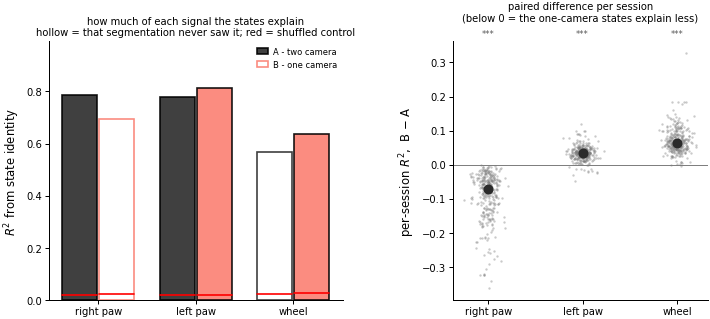

In [25]:
"""
RIGHT PAW PREDICTION: THE FIGURE
"""
fig, axs = plt.subplots(1, 2, figsize=(ps.FIG['double'][0], 2.8),
                        gridspec_kw={'wspace': 0.4, 'width_ratios': [1.15, 1]})

xx = np.arange(len(TARGET_COLS))
for off, tag, col in [(-0.19, SHORT_A, ps.STATE_INK), (0.19, SHORT_B, ps.SYLLABLE['Paw 3'])]:
    vals = [rp_wide.loc[t, tag] for t in TARGET_COLS]
    # hollow bar where that segmentation never saw the signal
    edges = ['none' if tag in SAW[t] else col for t in TARGET_COLS]
    faces = [col if tag in SAW[t] else 'white' for t in TARGET_COLS]
    axs[0].bar(xx + off, vals, width=0.36, color=faces, edgecolor=edges, lw=1.0,
               alpha=0.9, label=f'{tag} - {"two" if tag == SHORT_A else "one"} camera')
    for x, t in zip(xx, TARGET_COLS):
        sh = rp.loc[(rp['target'] == t) & (rp['segmentation'] == tag), 'R2 shuffled'].iloc[0]
        axs[0].plot([x + off - 0.18, x + off + 0.18], [sh, sh], color='r', lw=1.0, zorder=3)
axs[0].set_xticks(xx)
axs[0].set_xticklabels(list(TARGET_COLS))
axs[0].set_ylabel('$R^2$ from state identity')
axs[0].set_ylim(0, max(rp_wide[[SHORT_A, SHORT_B]].to_numpy().max() * 1.22, 0.5))
axs[0].legend(fontsize=5, frameon=False, loc='upper right')
axs[0].set_title('how much of each signal the states explain\n'
                 'hollow = that segmentation never saw it; red = shuffled control', fontsize=6)

for x, target in zip(xx, TARGET_COLS):
    d = rp_persession[target].to_numpy()
    axs[1].scatter(np.full(len(d), x) + rp_rng.normal(0, 0.07, len(d)), d,
                   s=2, color=ps.NEUTRAL, alpha=0.4, linewidths=0)
    axs[1].plot(x, np.median(d), 'o', ms=5, color=ps.STATE_INK, zorder=3)
    axs[1].text(x, 1.01, ps.stars(rp_wide.loc[target, 'wilcoxon p']),
                transform=axs[1].get_xaxis_transform(), ha='center', va='bottom',
                fontsize=5, color='0.35')
ps.zero_line(axs[1])
axs[1].set_xticks(xx)
axs[1].set_xticklabels(list(TARGET_COLS))
axs[1].set_ylabel('per-session $R^2$,  B $-$ A')
axs[1].set_title('paired difference per session\n(below 0 = the one-camera states explain less)',
                 fontsize=6, pad=12)
plt.show()

### Reading this section

The **right-paw row is the result**; the other two are the yardsticks.

- If B retains most of A's right-paw R², the wheel substitutes well for the missing camera. The
  printout above states this as a percentage, and the left-paw row gives the "no information
  difference" baseline to compare that gap against — a right-paw gap of the same size as the
  left-paw gap would mean the missing camera costs nothing beyond ordinary fitting variation.
- The shuffled control (red bars) should sit near zero. If it does not, the R² is being carried by
  something other than moment-to-moment alignment — a per-session offset that survived the
  z-scoring, most likely — and the absolute numbers cannot be trusted.
- R² here is high because the target is band-limited *movement energy* and the dominant distinction
  the states make is moving versus still. That is not a flaw, but it does mean the interesting
  variation is in the differences between the bars, not their height.

Two honest limits. **First**, this is not restricted by right-camera QC. All 332 sessions passed the
exclusions in `../5_syllable_generation.ipynb`, but a session with poor right-paw tracking makes A's
right-paw R² look worse *and* makes the target itself noise, which pushes the comparison in an
unpredictable direction. Intersecting with the video QC in `../data_query/` and re-running is the
proper version, and the per-session panel is where such sessions would show up as an outlying tail.
**Second**, a per-state mean is a deliberately blunt model. It measures the information in the state
*label*, which is the right question here, but it gives no credit for information in the state
*sequence* — the same limitation as the bag-of-syllables features in section 4.

---
# 6. Questions still open

Nothing implemented here — this is the reasoning, and what each idea would cost.

## 6a. How much information does each segmentation capture?

"Information" needs a target, and there are three genuinely different targets. They can disagree,
and the disagreement is the interesting part.

**(i) About the behaviour itself — how good a compression is it?**
The segmentation is a lossy code for the paw/wheel traces. The currency is *bits per bin*: the
marginal entropy `H(S)` says how much of the alphabet is actually used (a segmentation that spends
6 of 8 states on 2% of bins has a smaller effective alphabet than `log2(8) = 3` bits), and the
residual variance of the wavelet features *within* a state says how much behaviour survives the
quantisation. The catch: A and B are **not** codes for the same signal. A codes both paws; B codes
left paw + wheel, so B loses any both-paws reconstruction and wins any wheel reconstruction by
construction.

**Reconstructing the left paw is the weakest version of this, and probably not worth running.** It
looks symmetric — both segmentations saw the left paw — but it is not. For B the left paw is a
*direct input*, alongside a wheel signal that is itself strongly coupled to paw motion; for A the
left paw is only half the input. B should win, and winning would say nothing about whether B is the
better segmentation for anything the paper claims. On top of that, at k = 8 the residual is
dominated by how coarse the quantisation is rather than by which signals went in, so the two would
land close together for a reason unrelated to the camera. It is a codec benchmark for something
that is not a codec.

**The version worth running instead — can each segmentation's states predict the RIGHT paw? — is
now implemented: see section 5.** A saw it; B never did, so it tests the actual claim at issue on a
signal B has no access to. Section 5 also carries the left paw (both saw it) as a calibration row
and the wheel (only B saw it) as the mirror-image anchor. What it does *not* yet do is restrict to
sessions passing right-camera QC, which is the one refinement still worth adding — see the notes at
the end of that section.

**(ii) About the task — predictivity. Implemented: see section 4.**
Scored on variables neither segmentation was fit to, matched trial-for-trial and fold-for-fold.
Two extensions worth adding to it: swap the bag-of-syllables features for a *sequence* model (the
ordering is discarded at present, and ordering is what the syllables were built for), and add
**reaction time** as a continuous target — the trial table does not carry it yet, but it is the
`reaction` column of the frame-level `states_files`, joined on `session` + `trial_id`.

**(iii) About the mouse — individuality.**
These syllables exist to do LDA on mice. So: does LDA1 built on B recover the same mouse axis as
LDA1 built on A? Cross-validated mouse-identity accuracy under each, plus the correlation between
the two per-session LDA1 scores. Two segmentations with mediocre bin-by-bin agreement can still
induce nearly the same mouse embedding — the individuality signal lives in occupancy and transition
statistics, which the cross-session occupancy panel above already shows are well correlated. If
LDA1_A ≈ LDA1_B at r > 0.9, the bin-level disagreement is close to irrelevant for every conclusion
in the paper, and *that* is the result worth stating. One change is required before section 4's
setup can be reused here: the cross-validation has to group by **mouse**, not by session, or mouse
identity leaks straight through.

**A trap on all three.** Never compare `H(S)`, a decoder score, or a reconstruction error across
segmentations with different `k`, different missing-bin rates, or different numbers of *occupied*
states. A drops 1.0% of bins, B drops 0.15%; the comparison set has to be the intersection (as it
is above), and the alphabets have to be equally used or the entropies are not comparable. Fix `k`,
fix the bins, and report everything as a *difference* between the two.

## 6b. What kind of data makes the segmentation diverge more?

The two differ in exactly one input swap: **right paw out, wheel in**. So the prediction is not
"they diverge randomly" but "they diverge wherever the right paw carries information the wheel does
not, and vice versa". Worth conditioning the disagreement on, roughly in order of how much it would
tell you:

- **Trial epoch.** The wheel is informative during Choice and silent during Quiescence; the right
  paw moves in both. So expect agreement *highest during Choice* (wheel and paw track the same
  turning movement) and *lowest in Quiescence and ITI*, where B has only one paw and no wheel signal
  to lean on while A still has a second paw. One `groupby('broader_label')` — the first thing to
  look at, and the cheapest.
- **Which state / movement amplitude.** The matched-pair table above already hints at it: the
  high-occupancy quiescent states agree well, the sparse high-movement states scatter. Conditioning
  disagreement on A's state and on trace speed separates "they disagree about *what* the mouse is
  doing" from "they disagree about *when* a bout starts" — boundary jitter, which a dwell-time or
  transition-aligned analysis isolates.
- **Choice side.** The sharpest test of what the right paw contributes. A left and a right turn are
  different *both-paw* configurations but produce mirror-image wheel signals of similar magnitude.
  If disagreement is asymmetric between left and right choices, the right paw was carrying
  laterality the wheel cannot recover — a real information loss, not a labelling quibble.
- **Video / tracking quality.** The obvious confound, and it runs the *opposite* way from the naive
  reading: sessions with a bad right camera or poor right-paw LP traces should show high
  disagreement because A is noise there, not because B failed. The per-session ARI tail above is
  where to start, cross-referenced against the video QC in `../data_query/` and the sessions already
  excluded in `../5_syllable_generation.ipynb`. Separating "B loses information" from "A was never
  trustworthy in this session" is essential.
- **Mouse.** Mice with a strong paw preference are where the missing right paw should cost most. If
  disagreement is mouse-structured rather than session-structured, the divergence is behavioural,
  not technical — and it bears directly on the individuality claim, because it would mean B is
  blind to precisely the axis the paper is about.
- **Rate and dwell time.** One segmentation may simply flicker faster. Comparing transition rates
  and dwell-time distributions separates "a different partition of behaviour" from "the same
  partition with noisier boundaries". Per `../4.1_hmm_inspect.ipynb`, boundary jitter of a frame or
  two is expected and should not be counted as divergence.

**The framing that keeps this honest:** bin-level agreement is the wrong thing to optimise. The
question is not whether B reproduces A — it cannot, and A is not ground truth — but whether every
*downstream conclusion* is the same under both. Sort the divergence by whether it moves those
conclusions, and most of it will turn out not to.